# SMS Spam Classification Pipeline
This notebook builds an end-to-end NLP pipeline to classify SMS messages as either 'Ham' (normal) or 'Spam'.

## 1. Data Loading and Initial Exploration
Let's load the dataset and take a look at its structure.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
df=pd.read_csv('sms.csv',sep='\t',names=['Status','Message'])


## 2. Exploratory Data Analysis (EDA)
Before we train a model, let us understand our data. We will look at:
1. Class distribution (Ham vs. Spam)
2. Message lengths
3. Most frequent words (Word Clouds)

C:\Users\Asus\AppData\Local\Temp\ipykernel_18656\3865757692.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Status", palette="Set2")


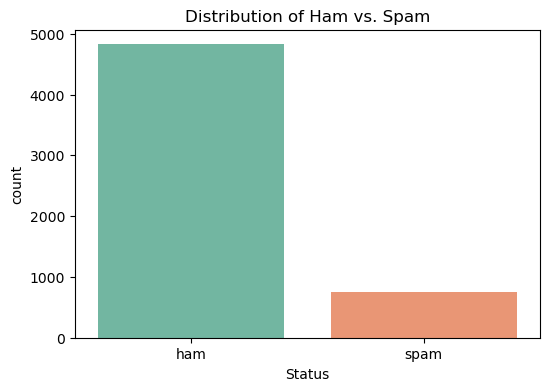

Total emails: 5572
Ham emails: 4825
Spam emails: 747


In [4]:
# 1. Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Status", palette="Set2")
plt.title("Distribution of Ham vs. Spam")
plt.show()

print("Total emails:", len(df))
print("Ham emails:", len(df[df["Status"]=="ham"]))
print("Spam emails:", len(df[df["Status"]=="spam"]))

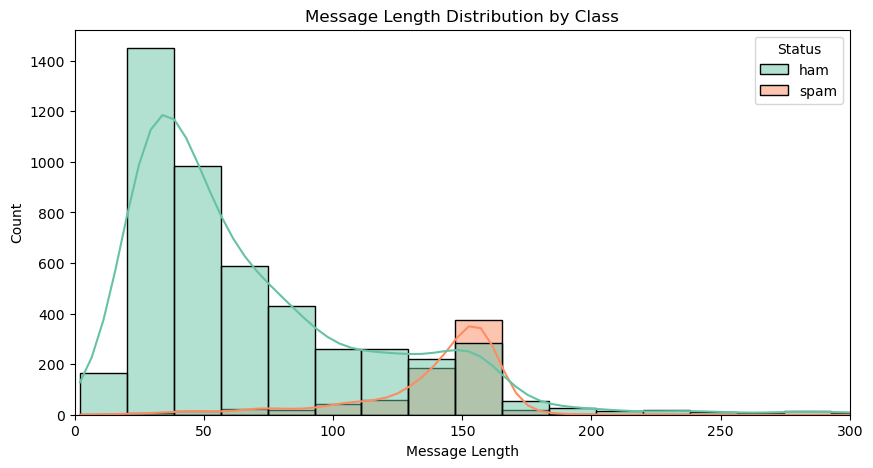

In [5]:
# 2. Message Length Analysis
df["length"] = df["Message"].apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="length", hue="Status", bins=50, kde=True, palette="Set2")
plt.title("Message Length Distribution by Class")
plt.xlabel("Message Length")
plt.xlim(0, 300) # Zooming in on the bulk of the data
plt.show()

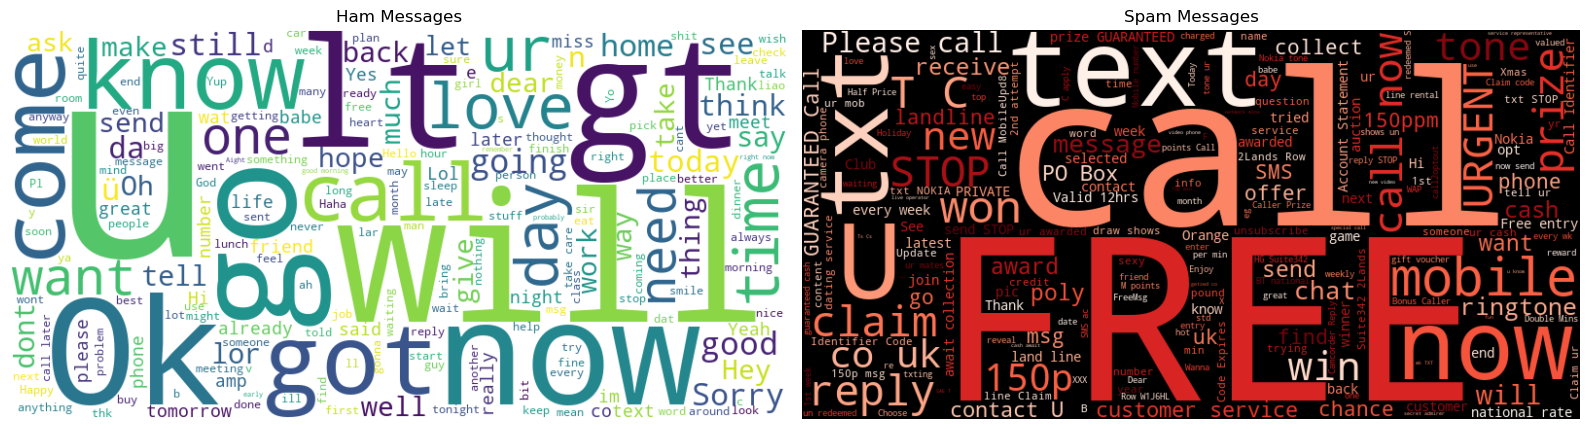

In [6]:
# 3. Word Clouds
ham_words = " ".join(list(df[df["Status"] == "ham"]["Message"]))
spam_words = " ".join(list(df[df["Status"] == "spam"]["Message"]))

plt.figure(figsize=(16, 8))

# Ham Word Cloud
plt.subplot(1, 2, 1)
wordcloud_ham = WordCloud(width=800, height=400, background_color="white").generate(ham_words)
plt.imshow(wordcloud_ham, interpolation="bilinear")
plt.title("Ham Messages")
plt.axis("off")

# Spam Word Cloud
plt.subplot(1, 2, 2)
wordcloud_spam = WordCloud(width=800, height=400, background_color="black", colormap="Reds").generate(spam_words)
plt.imshow(wordcloud_spam, interpolation="bilinear")
plt.title("Spam Messages")
plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
df.head()

,Status,Message,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [8]:
print("Total emails:", len(df))
print("Ham emails:", len(df[df['Status']=='ham']))
print("Spam emails:", len(df[df['Status']=='spam']))

Total emails: 5572
Ham emails: 4825
Spam emails: 747


In [9]:
# Cleanly map string labels to binary integers (0 = Ham, 1 = Spam)
df['Status'] = df['Status'].map({'ham': 0, 'spam': 1})
df.head()

,Status,Message,length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [10]:
df.head()

,Status,Message,length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [11]:
x_train, x_test, y_train, y_test = train_test_split(df["Message"], df["Status"], test_size=0.2, random_state=4)
print(f"Training set size: {len(x_train)}")
print(f"Test set size: {len(x_test)}")

Training set size: 4457
Test set size: 1115


## 5. Conclusion
Using a standard Naive Bayes classifier via a scikit-learn pipeline, we were able to quickly and effectively distinguish between normal SMS messages ("Ham") and Spam. We observed initially through our EDA that Spam messages tend to be longer and contain specific keywords ("FREE", "URGENT", "TXT").

The `classification_report` confirms our model's success, particularly on the **Precision** of detecting Spam—which is crucial in a real-world scenario to prevent legitimate messages from being accidentally hidden from a user!